# House Value Prediction (Python, scikit-learn)

This notebook builds regression models to predict `median_house_value` from the other columns in `data/houses.csv`.

It includes:
- Data loading and basic checks
- Train/validation split with cross-validation
- Baselines: mean predictor and LinearRegression
- Regularized models: Ridge, Lasso
- Tree-based models: RandomForestRegressor, GradientBoostingRegressor
- Scaling and preprocessing via `ColumnTransformer` and `Pipeline`
- Evaluation with RMSE and R^2
- Feature importance for tree models

Requirements (see `requirements.txt`): pandas, numpy, scikit-learn, matplotlib, seaborn



In [1]:
# Imports and configuration
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import sklearn
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)

DATA_PATH = Path("data/houses.csv")
assert DATA_PATH.exists(), f"Missing {DATA_PATH}. Run ./setup.sh to unzip data."



In [2]:
# Load data
raw = pd.read_csv(DATA_PATH)
print(raw.shape)
raw.head()


(20640, 9)


,median_house_value,median_income,housing_median_age,total_rooms,total_bedrooms,population,households,latitude,longitude
0,452600.0,8.3252,41.0,880.0,129.0,322.0,126.0,37.88,-122.23
1,358500.0,8.3014,21.0,7099.0,1106.0,2401.0,1138.0,37.86,-122.22
2,352100.0,7.2574,52.0,1467.0,190.0,496.0,177.0,37.85,-122.24
3,341300.0,5.6431,52.0,1274.0,235.0,558.0,219.0,37.85,-122.25
4,342200.0,3.8462,52.0,1627.0,280.0,565.0,259.0,37.85,-122.25


In [3]:
# Basic EDA and target/feature setup
# Identify target and feature columns by name from known schema
# The CSV columns (from R notebook sample):
# median_house_value (target), median_income, housing_median_age, total_rooms,
# total_bedrooms, population, households, latitude, longitude

expected_cols = [
    "median_house_value",
    "median_income",
    "housing_median_age",
    "total_rooms",
    "total_bedrooms",
    "population",
    "households",
    "latitude",
    "longitude",
]
missing = [c for c in expected_cols if c not in raw.columns]
assert not missing, f"Missing columns: {missing}"

# Quick numeric summary
raw.describe().T


,count,mean,std,min,25%,50%,75%,max
median_house_value,20640.0,206855.816909,115395.615874,14999.0000,119600.0000,179700.0000,264725.00000,500001.0000
median_income,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
housing_median_age,20640.0,28.639486,12.585558,1.0000,18.0000,29.0000,37.00000,52.0000
total_rooms,20640.0,2635.763081,2181.615252,2.0000,1447.7500,2127.0000,3148.00000,39320.0000
total_bedrooms,20640.0,537.898014,421.247906,1.0000,295.0000,435.0000,647.00000,6445.0000
population,20640.0,1425.476744,1132.462122,3.0000,787.0000,1166.0000,1725.00000,35682.0000
households,20640.0,499.539680,382.329753,1.0000,280.0000,409.0000,605.00000,6082.0000
latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500
longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100


In [4]:
# Train/Validation split
TARGET = "median_house_value"
FEATURES = [c for c in raw.columns if c != TARGET]

X = raw[FEATURES].copy()
y = raw[TARGET].copy()

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
X_train.shape, X_valid.shape


((16512, 8), (4128, 8))

In [5]:
# Preprocessing: Impute and scale numeric features
num_features = X_train.columns.tolist()

numeric_preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

preprocess = ColumnTransformer(
    transformers=[("num", numeric_preprocess, num_features)], remainder="drop"
)

preprocess


,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [6]:
# Helper: evaluation
from math import sqrt


def evaluate(model, X_tr=X_train, y_tr=y_train, X_te=X_valid, y_te=y_valid, name=None):
    pred_tr = model.predict(X_tr)
    pred_te = model.predict(X_te)
    rmse_tr = sqrt(mean_squared_error(y_tr, pred_tr))
    rmse_te = sqrt(mean_squared_error(y_te, pred_te))
    r2_tr = r2_score(y_tr, pred_tr)
    r2_te = r2_score(y_te, pred_te)
    label = name or model.__class__.__name__
    return {
        "model": label,
        "rmse_train": rmse_tr,
        "rmse_valid": rmse_te,
        "r2_train": r2_tr,
        "r2_valid": r2_te,
    }



In [7]:
# Baseline: mean predictor
baseline = Pipeline([
    ("pre", preprocess),
    ("est", DummyRegressor(strategy="mean")),
])
baseline.fit(X_train, y_train)
base_metrics = evaluate(baseline, name="DummyMean")
base_metrics


{'model': 'DummyMean',
 'rmse_train': 115619.12522543264,
 'rmse_valid': 114485.63543099792,
 'r2_train': 0.0,
 'r2_valid': -0.00021908714592466794}

In [8]:
# Linear models
linreg = Pipeline([
    ("pre", preprocess),
    ("est", LinearRegression()),
])
linreg.fit(X_train, y_train)
lin_metrics = evaluate(linreg, name="LinearRegression")

ridge = Pipeline([
    ("pre", preprocess),
    ("est", Ridge(random_state=RANDOM_STATE)),
])
ridge_params = {"est__alpha": [0.1, 1.0, 10.0, 100.0]}
ridge_cv = GridSearchCV(ridge, ridge_params, cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1)
ridge_cv.fit(X_train, y_train)
ridge_best = ridge_cv.best_estimator_
ridge_metrics = evaluate(ridge_best, name=f"Ridge(alpha={ridge_cv.best_params_['est__alpha']})")

lasso = Pipeline([
    ("pre", preprocess),
    ("est", Lasso(random_state=RANDOM_STATE, max_iter=10000)),
])
lasso_params = {"est__alpha": [0.001, 0.01, 0.1, 1.0]}
lasso_cv = GridSearchCV(lasso, lasso_params, cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1)
lasso_cv.fit(X_train, y_train)
lasso_best = lasso_cv.best_estimator_
lasso_metrics = evaluate(lasso_best, name=f"Lasso(alpha={lasso_cv.best_params_['est__alpha']})")

lin_metrics, ridge_metrics, lasso_metrics


({'model': 'LinearRegression',
  'rmse_train': 69362.34135238081,
  'rmse_valid': 70132.42075871778,
  'r2_train': 0.6400947924305292,
  'r2_valid': 0.6246548578993616},
 {'model': 'Ridge(alpha=10.0)',
  'rmse_train': 69363.14052064605,
  'rmse_valid': 70131.5784840712,
  'r2_train': 0.640086498982767,
  'r2_valid': 0.6246638734671996},
 {'model': 'Lasso(alpha=1.0)',
  'rmse_train': 69362.34188747255,
  'rmse_valid': 70132.36840581168,
  'r2_train': 0.6400947868775939,
  'r2_valid': 0.6246554182793238})

In [9]:
# Tree-based models
rf = Pipeline([
    ("pre", preprocess),
    ("est", RandomForestRegressor(random_state=RANDOM_STATE, n_estimators=400, n_jobs=-1)),
])
rf.fit(X_train, y_train)
rf_metrics = evaluate(rf, name="RandomForest")

# A small grid for GBoost
gbr = Pipeline([
    ("pre", preprocess),
    ("est", GradientBoostingRegressor(random_state=RANDOM_STATE)),
])
gbr_params = {
    "est__n_estimators": [200, 400],
    "est__learning_rate": [0.05, 0.1],
    "est__max_depth": [2, 3],
}
gbr_cv = GridSearchCV(gbr, gbr_params, cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1)
gbr_cv.fit(X_train, y_train)
gbr_best = gbr_cv.best_estimator_
gbr_metrics = evaluate(gbr_best, name=f"GradientBoosting({gbr_cv.best_params_})")

rf_metrics, gbr_metrics


({'model': 'RandomForest',
  'rmse_train': 18090.466511833645,
  'rmse_valid': 49465.72379038693,
  'r2_train': 0.9755183787609992,
  'r2_valid': 0.8132752544635701},
 {'model': "GradientBoosting({'est__learning_rate': 0.1, 'est__max_depth': 3, 'est__n_estimators': 400})",
  'rmse_train': 43624.725439808215,
  'rmse_valid': 49727.42140041871,
  'r2_train': 0.8576340747541722,
  'r2_valid': 0.8112942997037198})

In [10]:
# Neural network model (MLP)
mlp = Pipeline([
    ("pre", preprocess),
    ("est", MLPRegressor(hidden_layer_sizes=(128, 64), activation="relu", solver="adam",
                         learning_rate_init=1e-3, max_iter=500, random_state=RANDOM_STATE)),
])
mlp.fit(X_train, y_train)
mlp_metrics = evaluate(mlp, name="MLPRegressor(128,64)")
mlp_metrics


{'model': 'MLPRegressor(128,64)',
 'rmse_train': 63382.410344805154,
 'rmse_valid': 64448.92551330459,
 'r2_train': 0.6994767040869392,
 'r2_valid': 0.6830253707971854}

In [11]:
# Compare metrics
results = pd.DataFrame([
    base_metrics,
    lin_metrics,
    ridge_metrics,
    lasso_metrics,
    rf_metrics,
    gbr_metrics,
    mlp_metrics,
]).sort_values("rmse_valid")
results.reset_index(drop=True)


,model,rmse_train,rmse_valid,r2_train,r2_valid
0,RandomForest,18090.466512,49465.723790,0.975518,0.813275
1,"GradientBoosting({'est__learning_rate': 0.1, '...",43624.725440,49727.421400,0.857634,0.811294
2,"MLPRegressor(128,64)",63382.410345,64448.925513,0.699477,0.683025
3,Ridge(alpha=10.0),69363.140521,70131.578484,0.640086,0.624664
4,Lasso(alpha=1.0),69362.341887,70132.368406,0.640095,0.624655
5,LinearRegression,69362.341352,70132.420759,0.640095,0.624655
6,DummyMean,115619.125225,114485.635431,0.000000,-0.000219


In [12]:
# Persist best model (RandomForest)
from joblib import dump

models_dir = Path("models")
models_dir.mkdir(exist_ok=True)

artifact = {
    "model": rf,  # Pipeline(preprocess -> RandomForestRegressor)
    "metrics": rf_metrics,
    "sklearn_version": sklearn.__version__,
    "created_by": "houses_sklearn_regression.ipynb",
    "features": num_features,
    "target": TARGET,
}

outfile = models_dir / "house_value_rf.joblib"
dump(artifact, outfile)
outfile


PosixPath('models/house_value_rf.joblib')

In [13]:
# Feature importance (tree models)
# RF feature importances are accessible via the final estimator
rf_fi = rf.named_steps["est"].feature_importances_
fi = pd.Series(rf_fi, index=num_features).sort_values(ascending=False)
fi.to_frame("importance").head(10)


,importance
median_income,0.520919
longitude,0.155588
latitude,0.147461
housing_median_age,0.065435
population,0.037811
total_bedrooms,0.028445
total_rooms,0.024509
households,0.019832


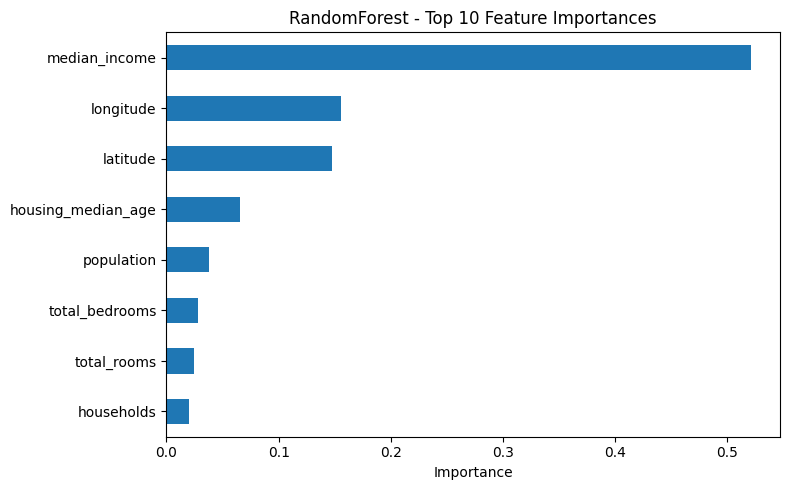

In [14]:
# Plot top features
plt.figure(figsize=(8, 5))
fi.head(10)[::-1].plot(kind="barh")
plt.title("RandomForest - Top 10 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


Notes
- All features are numeric, so preprocessing uses only numeric pipeline.
- Latitude/longitude are used as-is; adding engineered features (e.g., proximity to coast) may improve performance.
- You can expand hyperparameter grids for better models, at added compute cost.
- For reproducibility, set `RANDOM_STATE` and persist the best model if needed.


In [ ]:
# Export RandomForest pipeline to portable JSON (preprocessing + trees)
import json
from pathlib import Path

out_json = Path("models/house_value_rf.json")

pre = rf.named_steps["pre"]
num_pipe = pre.named_transformers_["num"]
imputer = num_pipe.named_steps["imputer"]
scaler = num_pipe.named_steps["scaler"]
forest = rf.named_steps["est"]

export = {
    "format": "houses_rf_v1",
    "features": num_features,
    "target": TARGET,
    "preprocess": {
        "imputer": {
            "strategy": imputer.strategy,
            "statistics": imputer.statistics_.tolist(),
        },
        "scaler": {
            "with_mean": bool(getattr(scaler, "with_mean", True)),
            "with_std": bool(getattr(scaler, "with_std", True)),
            "mean": (getattr(scaler, "mean_", None).tolist() if hasattr(scaler, "mean_") else None),
            "scale": (getattr(scaler, "scale_", None).tolist() if hasattr(scaler, "scale_") else None),
        },
    },
    "forest": {
        "n_estimators": forest.n_estimators,
        "trees": []
    },
}

for est in forest.estimators_:
    t = est.tree_
    tree_obj = {
        "children_left": t.children_left.tolist(),
        "children_right": t.children_right.tolist(),
        "feature": t.feature.tolist(),
        "threshold": t.threshold.tolist(),
        # Flatten the (n_nodes, 1, 1) to (n_nodes,)
        "value": [float(v[0][0]) for v in t.value.tolist()],
    }
    export["forest"]["trees"].append(tree_obj)

out_json.parent.mkdir(exist_ok=True)
with out_json.open("w", encoding="utf-8") as f:
    json.dump(export, f, indent=2)

out_json


In [ ]:
# Optional: export ONNX if available
try:
    from skl2onnx import convert_sklearn
    from skl2onnx.common.data_types import FloatTensorType
    import numpy as np

    sample_input = np.zeros((1, len(num_features)), dtype=np.float32)
    onnx_model = convert_sklearn(
        rf, initial_types=[("input", FloatTensorType([None, len(num_features)]))],
        target_opset=13,
    )
    onnx_path = Path("models/house_value_rf.onnx")
    with open(onnx_path, "wb") as f:
        f.write(onnx_model.SerializeToString())
    onnx_path
except Exception as e:
    print("ONNX export skipped:", e)

